# Phân tích & Dự đoán Giá Xe Hai Bánh Điện (Xe đạp điện & Xe máy điện)

Notebook này hướng dẫn quy trình từ phân tích khám phá dữ liệu (EDA), trích xuất và chuẩn hóa đặc trưng, đến huấn luyện các mô hình học máy (Linear Regression, SVR, Random Forest, XGBoost, LightGBM) để dự báo giá xe hai bánh điện tại Việt Nam.

## 1. Thiết lập Môi trường & Khai báo Thư viện

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("..")
sys.path.append(str(ROOT.resolve()))

from src.viz.style import (
    apply_style, latex_safe, add_bar_labels,
    PALETTE, COLOR_PRIMARY, COLOR_ACCENT, COLOR_GOOD, COLOR_BAD,
    TABLE_HEADER, TABLE_ROW_ALT,
    FIGSIZE_SINGLE, FIGSIZE_WIDE, FIGSIZE_TALL, FIGSIZE_TABLE,
)
apply_style()

# Disable LaTeX compiler for notebooks containing Vietnamese Unicode text
plt.rcParams["text.usetex"] = False

DATA_DIR = ROOT / "data" / "interim"
PROCESSED_DIR = ROOT / "data" / "processed" / "two_wheelers"
REPORTS_DIR = ROOT / "reports" / "two_wheelers"

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Phân tích Khám phá Dữ liệu (EDA)
Tải tập dữ liệu đã gộp sạch `two_wheelers_eda_ready.csv` và kiểm tra các thống kê cơ bản.

In [2]:
df = pd.read_csv(DATA_DIR / "two_wheelers_eda_ready.csv")
print(f"Tổng số bản ghi: {len(df):,}")
print(f"Các cột trong dữ liệu: {list(df.columns)}")
display(df.head(5))


Tổng số bản ghi: 2,079
Các cột trong dữ liệu: ['id', 'vehicle_type', 'sub_type', 'brand', 'model', 'year', 'mileage_km', 'condition', 'has_aftermarket_mods', 'origin', 'city', 'seller_name', 'post_date', 'link', 'price_vnd', 'title', 'description']


,id,vehicle_type,sub_type,brand,model,year,mileage_km,condition,has_aftermarket_mods,origin,city,seller_name,post_date,link,price_vnd,title,description
0,0,xe_dap_dien,Xe đạp điện,Unknown,i8,"2,023.00",NaN,Used,0,Việt Nam,Vũng Tàu,Thanh Nam,2026-06-23 19:22:35,https://xe.chotot.com/mua-ban-xe-dap/133150746.htm,5000000,Xe đạp điện i8 màu Hồng,dư xe đạp điện cần bán xe còn xin còn mới keng hãng i8 k...
1,1,xe_dap_dien,Xe đạp điện,Unknown,Unknown,"2,023.00",NaN,Used,0,Nhật Bản,Hồ Chí Minh,lan phuong,2026-06-23 19:13:10,https://xe.chotot.com/mua-ban-xe-dap/130984939.htm,2700000,Cần bán chiếc xe đạp điện đang chạy bình thường,Cần thanh lý xe đạp điện chính hãng bình còn chạy đc 25 ...
2,2,xe_dap_dien,Xe đạp điện,Yadea,Unknown,"2,023.00",NaN,Used,0,NaN,Hồ Chí Minh,Shop Xuân Mạnh chuyên nhận đóng pin máy khoan theo yêu c...,2026-06-23 18:55:18,https://xe.chotot.com/mua-ban-xe-dap/133150412.htm,1500000,Xe đạp điện Yadea Bạc hoạt động bình thường,xe đạp điện nội địa hoạt động bình thường không pin
3,3,xe_dap_dien,Xe đạp điện,Yadea,M133,"2,023.00",NaN,Used,0,NaN,Hồ Chí Minh,trần quốc minh,2026-06-23 18:19:13,https://xe.chotot.com/mua-ban-xe-dap/133149832.htm,3500000,Xe đạp điện Yadea M133 màu Đen,"Xe đạp điện màu đen, đã lên pin sạc nhanh cho hiệu suất ..."
4,4,xe_dap_dien,Xe đạp điện,Unknown,LENOX,"2,023.00",NaN,Used,0,Khác,Hồ Chí Minh,MUAXEĐIỆNGIÁCAO,2026-06-23 18:19:07,https://xe.chotot.com/mua-ban-xe-dap/133149830.htm,11500000,XE ĐẠP ĐIỆN NONEBAL LENOX LƯỚT 90% CÒN SỔ BH,XE ĐẠP ĐIỆN NONEBAL LENOX LƯỚT 90% CÒN SỔ BH BÌNH SẠC ĐẦ...


In [3]:
print("Tỷ lệ các loại xe điện:")
print(df['sub_type'].value_counts())

print("\nThống kê khuyết thiếu:")
print(df.isnull().sum())

print("\nprice_vnd Statistics")
print(df['price_vnd'].describe().apply(lambda x: format(x, 'f')))


Tỷ lệ các loại xe điện:
sub_type
Xe máy điện    1194
Xe đạp điện     885
Name: count, dtype: int64

Thống kê khuyết thiếu:
id                        0
vehicle_type              0
sub_type                  0
brand                     0
model                     0
year                      0
mileage_km              640
condition                 0
has_aftermarket_mods      0
origin                  416
city                      0
seller_name               0
post_date                 0
link                      0
price_vnd                 0
title                     0
description               0
dtype: int64

price_vnd Statistics
count         2079.000000
mean      12892254.187109
std       12328838.895839
min         500000.000000
25%        4200000.000000
50%        8500000.000000
75%       18000000.000000
max      175000000.000000
Name: price_vnd, dtype: str


### Trực quan hóa Phân phối Giá bán
So sánh giá của xe máy điện (`xe_may_dien`) và xe đạp điện (`xe_dap_dien`).

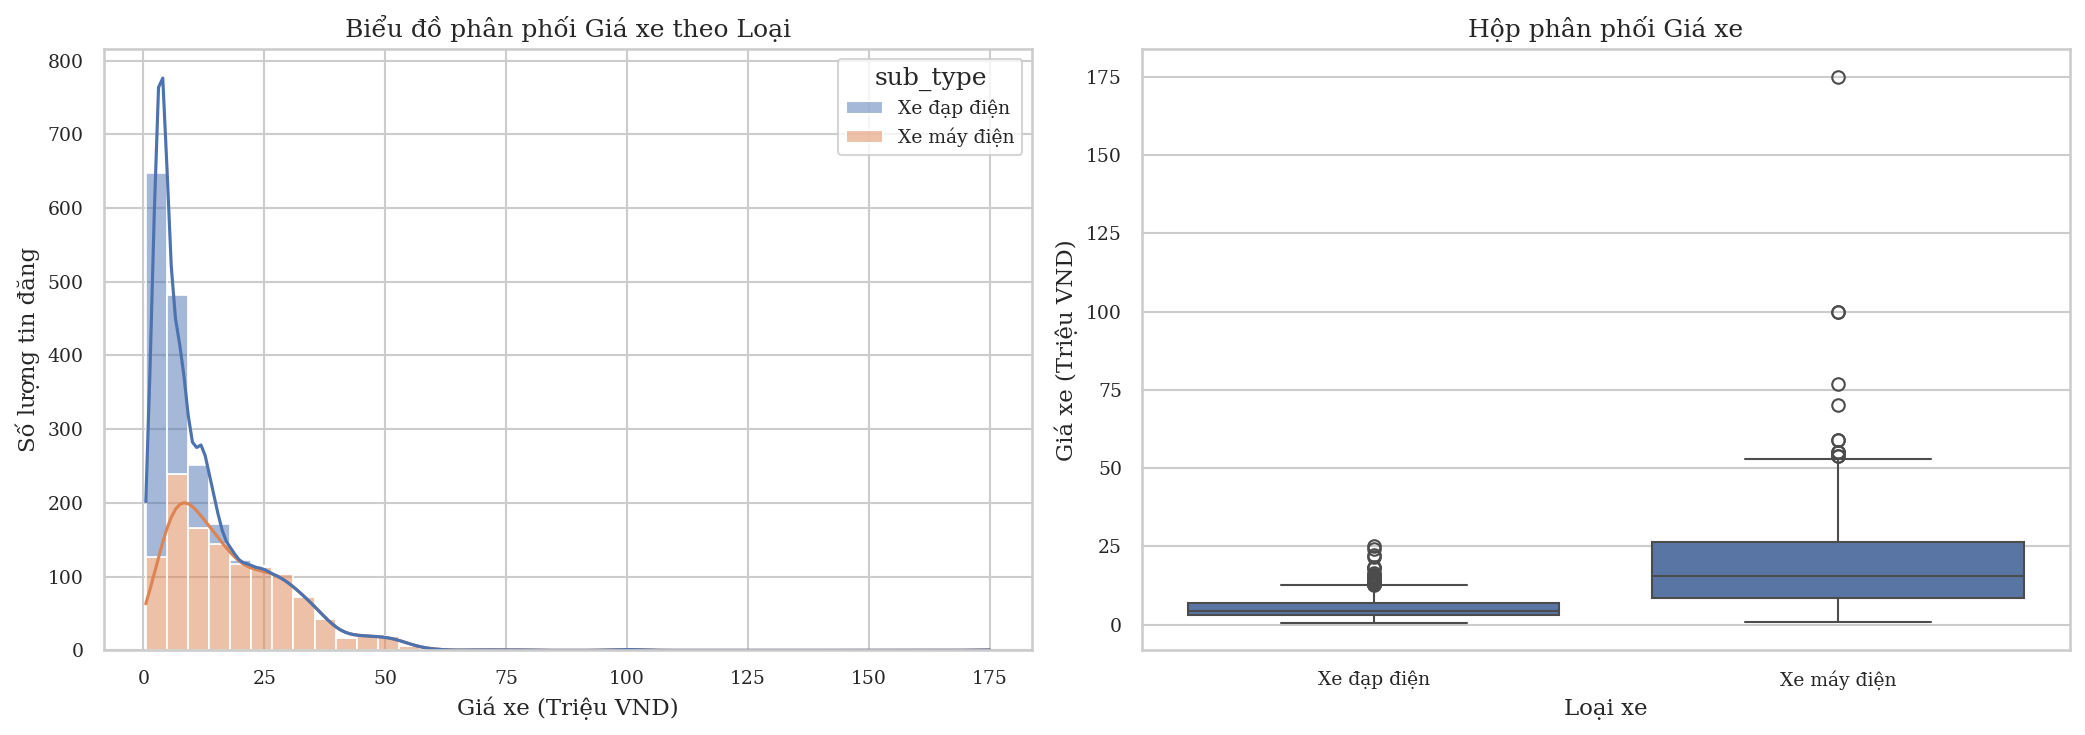

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối giá tổng quan
sns.histplot(data=df, x=df["price_vnd"] / 1e6, hue="sub_type", kde=True, bins=40, multiple="stack", ax=axes[0])
axes[0].set_xlabel("Giá xe (Triệu VND)")
axes[0].set_ylabel("Số lượng tin đăng")
axes[0].set_title("Biểu đồ phân phối Giá xe theo Loại")

# Hộp râu (Boxplot)
sns.boxplot(data=df, x="sub_type", y=df["price_vnd"] / 1e6, ax=axes[1])
axes[1].set_xlabel("Loại xe")
axes[1].set_ylabel("Giá xe (Triệu VND)")
axes[1].set_title("Hộp phân phối Giá xe")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "price_distribution_by_type.png", bbox_inches="tight")
plt.show()


### Phân phối Giá bán & Độ lệch (Skewness)


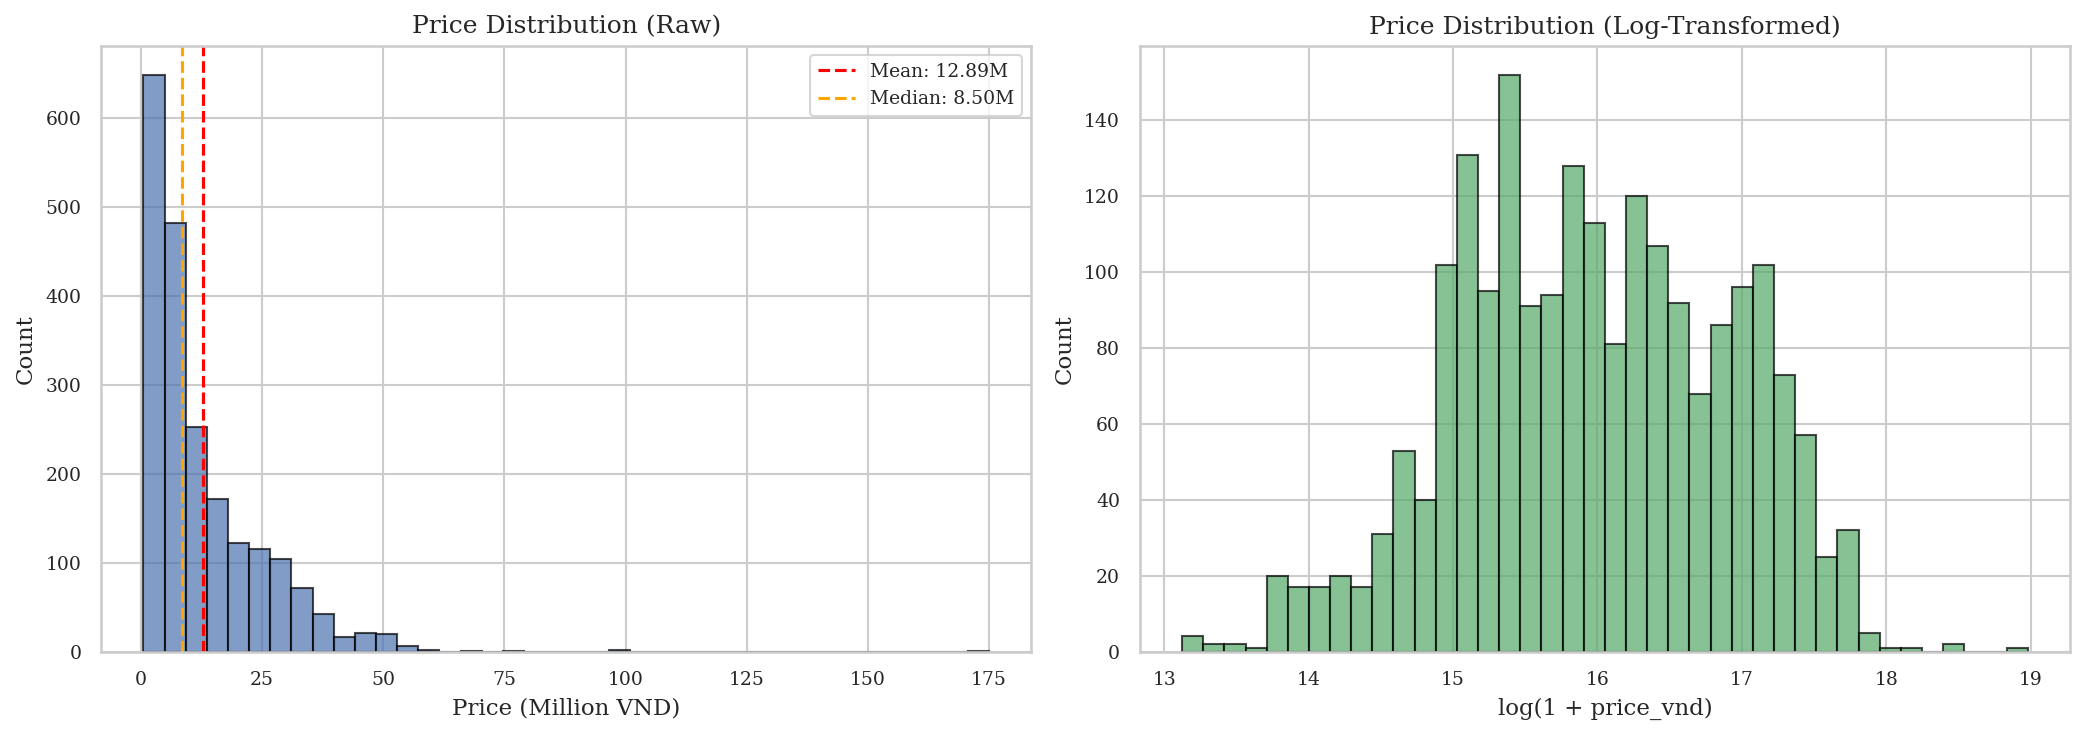

Price skewness (raw):        2.60
Price skewness (log):        -0.10


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
price = df["price_vnd"].dropna() / 1e6
axes[0].hist(price, bins=40, color=COLOR_PRIMARY, edgecolor="black", alpha=0.7)
axes[0].axvline(price.mean(), color="red", linestyle="--", label=f"Mean: {price.mean():.2f}M")
axes[0].axvline(price.median(), color="orange", linestyle="--", label=f"Median: {price.median():.2f}M")
axes[0].set_xlabel("Price (Million VND)")
axes[0].set_ylabel("Count")
axes[0].set_title("Price Distribution (Raw)")
axes[0].legend()

# Log-transformed
log_price = np.log1p(df["price_vnd"].dropna())
axes[1].hist(log_price, bins=40, color=COLOR_GOOD, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("log(1 + price_vnd)")
axes[1].set_ylabel("Count")
axes[1].set_title("Price Distribution (Log-Transformed)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "price_skewness_raw_vs_log.png", bbox_inches="tight")
plt.show()

print(f"Price skewness (raw):        {price.skew():.2f}")
print(f"Price skewness (log):        {log_price.skew():.2f}")


### Thống kê Tin đăng Đắt nhất & Rẻ nhất


In [6]:
print("=" * 80)
print("TOP 10 TIN ĐĂNG CÓ GIÁ CAO NHẤT")
print("=" * 80)
top10 = df.nlargest(10, "price_vnd")[["brand", "model", "sub_type", "year", "condition", "mileage_km", "price_vnd"]].copy()
top10["price_M"] = top10["price_vnd"] / 1e6
print(top10.to_string(index=False))

print("\n" + "=" * 80)
print("TOP 10 TIN ĐĂNG CÓ GIÁ THẤP NHẤT")
print("=" * 80)
bottom10 = df.nsmallest(10, "price_vnd")[["brand", "model", "sub_type", "year", "condition", "mileage_km", "price_vnd"]].copy()
bottom10["price_M"] = bottom10["price_vnd"] / 1e6
print(bottom10.to_string(index=False))


TOP 10 TIN ĐĂNG CÓ GIÁ CAO NHẤT
   brand            model    sub_type     year condition  mileage_km  price_vnd  price_M
 Unknown          Evo max Xe máy điện 2,026.00      Used       10.00  175000000   175.00
 Unknown        Quantum S Xe máy điện 2,026.00      Used      800.00  100000000   100.00
 Unknown          Unknown Xe máy điện     0.00      Used        0.00   99999999   100.00
 VinFast            Feliz Xe máy điện 2,022.00      Used    7,000.00   77000000    77.00
 Unknown          Scooter Xe máy điện 2,025.00      Used       48.00   70000000    70.00
 VinFast           TheonS Xe máy điện 2,025.00      Used    3,500.00   59000000    59.00
 Unknown           XSR155 Xe máy điện 2,020.00      Used       20.00   59000000    59.00
 Unknown VENTOS Lướt 6900 Xe máy điện 2,024.00      Used    6,900.00   55000000    55.00
 VinFast           Vero X Xe máy điện 2,026.00      Used      600.00   55000000    55.00
Dat Bike          Theon S Xe máy điện 2,025.00      Used    1,000.00   5500000

### Hãng xe phổ biến nhất
Hiển thị Top các hãng xe hai bánh điện xuất hiện nhiều nhất.

C:\Users\bumbum\AppData\Local\Temp\ipykernel_6176\3815557635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_counts.values, y=brand_counts.index, palette="viridis")


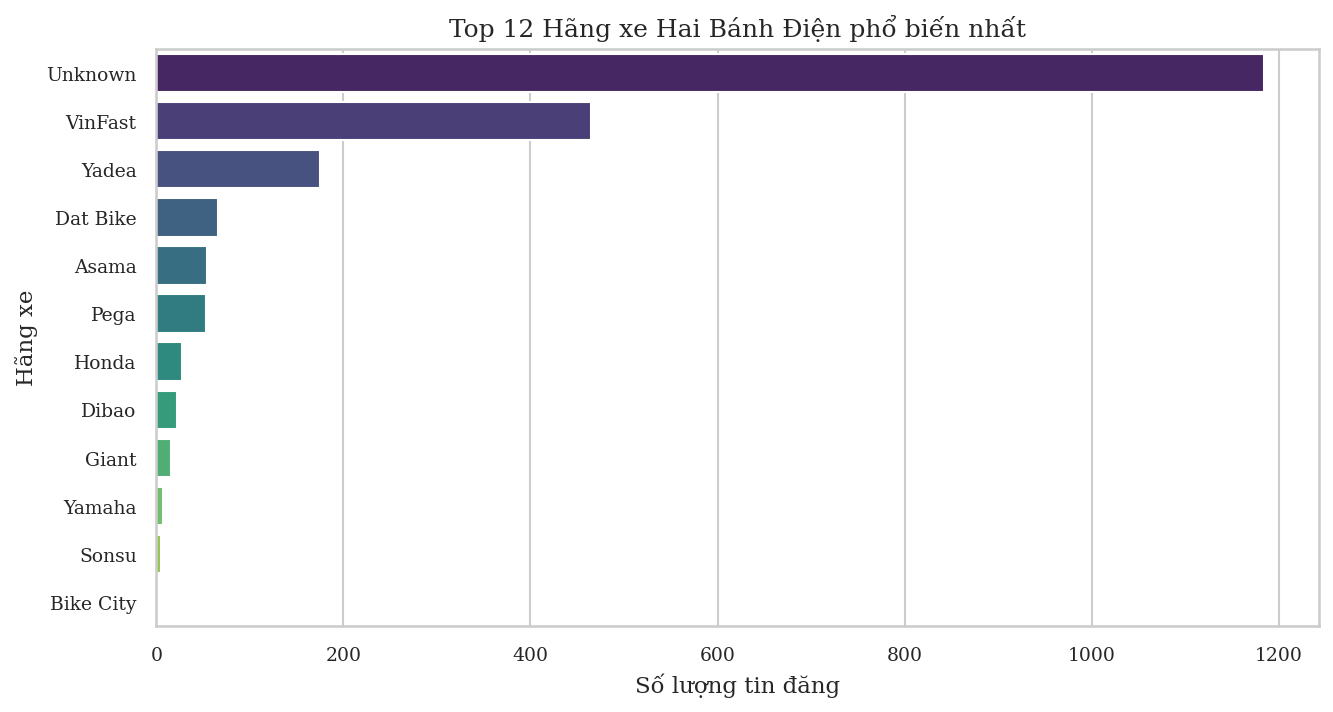

In [7]:
plt.figure(figsize=(10, 5))
brand_counts = df['brand'].value_counts().head(12)
sns.barplot(x=brand_counts.values, y=brand_counts.index, palette="viridis")
plt.xlabel("Số lượng tin đăng")
plt.ylabel("Hãng xe")
plt.title("Top 12 Hãng xe Hai Bánh Điện phổ biến nhất")
plt.savefig(REPORTS_DIR / "top_12_brands.png", bbox_inches="tight")
plt.show()


## 3. Chạy Quy trình Tạo Đặc trưng (Feature Engineering)
Tiến hành tiền xử lý, điền khuyết thiếu theo giá trị trung vị của tập Train (để tránh rò rỉ dữ liệu - target leakage), ánh xạ thông số kỹ thuật (Pin, Quãng đường, Công suất), mã hóa và phân tách dữ liệu thành tập Train/Test.

In [8]:
# Chạy file xử lý đặc trưng
exec(open(ROOT / "src" / "features" / "build_features_twowheeler.py", encoding="utf-8").read())


2026-06-25 21:07:21.946 | INFO     | __main__:main:74 - === STEP 2: TWO-WHEELERS FEATURE ENGINEERING ===
2026-06-25 21:07:21.964 | INFO     | __main__:main:81 - Loaded 2079 records from two_wheelers_eda_ready.csv
2026-06-25 21:07:22.024 | INFO     | __main__:main:133 - Rescaled 3 low-priced two-wheelers (< 1M) using ratio-to-median
2026-06-25 21:07:22.026 | INFO     | __main__:main:142 - Filtered out 11 price outliers (price < 1M or > 80M). Remaining: 2068
2026-06-25 21:07:22.026 | INFO     | __main__:main:148 - Treating 14 invalid years (< 2010) as NaN
2026-06-25 21:07:22.027 | INFO     | __main__:main:155 - Capping 20 extreme mileages (> 100,000 km) at 100,000 km
2026-06-25 21:07:22.040 | INFO     | __main__:main:176 - Split data into Train: 1654 rows, Test: 414 rows
2026-06-25 21:07:22.051 | WARNING  | __main__:main:222 - Dropping non-numeric columns: ['sub_type']
2026-06-25 21:07:22.163 | SUCCESS  | __main__:main:254 - Feature engineering completed! Train size: (1654, 68), Test siz

## 4. Huấn luyện các mô hình học máy & Đánh giá (Model Benchmarking)
Chạy huấn luyện cho 5 thuật toán chính: **Linear Regression, SVR, Random Forest, XGBoost, và LightGBM**. Lưu kết quả đo lường độ chính xác.

In [9]:
# Chạy file huấn luyện mô hình
exec(open(ROOT / "src" / "models" / "train_twowheeler.py", encoding="utf-8").read())


=== STEP 3: HUẤN LUYỆN & SO SÁNH MÔ HÌNH XE HAI BÁNH ===
Train features shape: (1654, 68)
Test features shape: (414, 68)
Huấn luyện Linear Regression...
Huấn luyện SVR...
Huấn luyện Random Forest...
Huấn luyện XGBoost...
Huấn luyện LightGBM...

Bảng so sánh kết quả các mô hình:
            Model  Train R2  Test R2  Train MAE (VND)  Test MAE (VND)  Train RMSE (VND)  Test RMSE (VND)  Train MAPE (%)  Test MAPE (%)
Linear Regression      0.65     0.62     4,239,448.44    4,496,434.33      6,845,089.54     6,974,344.82           51.33          57.47
              SVR      0.74     0.76     3,564,897.55    3,819,822.07      5,920,570.76     5,544,475.98           48.74          57.03
    Random Forest      0.86     0.75     1,980,373.82    3,927,546.69      4,262,146.77     5,610,716.71           22.64          61.00
          XGBoost      0.83     0.78     2,525,167.00    3,685,598.50      4,800,216.24     5,289,335.39           27.12          57.51
         LightGBM      0.80     0.76     

<string>:195: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



### Bảng so sánh kết quả các mô hình
Hiển thị chi tiết bảng kết quả để đánh giá mô hình tối ưu.

In [10]:
metrics_df = pd.read_csv(REPORTS_DIR / "model_metrics.csv")
display(metrics_df.sort_values(by="Test R2", ascending=False))


,Model,Train R2,Test R2,Train MAE (VND),Test MAE (VND),Train RMSE (VND),Test RMSE (VND),Train MAPE (%),Test MAPE (%)
3,XGBoost,0.83,0.78,"2,525,167.00","3,685,598.50","4,800,216.24","5,289,335.39",27.12,57.51
1,SVR,0.74,0.76,"3,564,897.55","3,819,822.07","5,920,570.76","5,544,475.98",48.74,57.03
4,LightGBM,0.80,0.76,"2,744,860.28","3,905,870.25","5,159,605.17","5,561,799.53",30.46,60.10
2,Random Forest,0.86,0.75,"1,980,373.82","3,927,546.69","4,262,146.77","5,610,716.71",22.64,61.00
0,Linear Regression,0.65,0.62,"4,239,448.44","4,496,434.33","6,845,089.54","6,974,344.82",51.33,57.47


### Phân phối Giá bán Tập Train vs Test


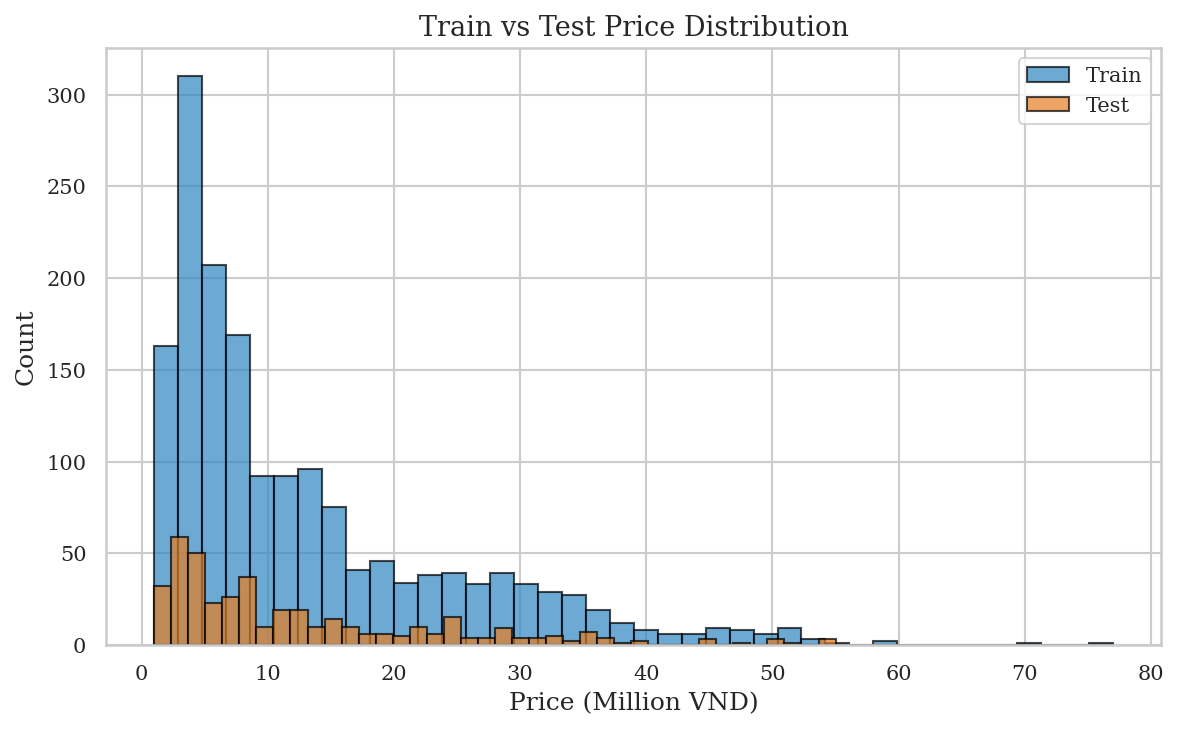


Train price stats (M VND): mean=12.85, median=8.50, std=11.53
Test price stats  (M VND): mean=12.53, median=8.50, std=11.33


In [11]:
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["price_vnd"]
y_test_s = pd.read_csv(PROCESSED_DIR / "y_test.csv")["price_vnd"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_train / 1e6, bins=40, color=COLOR_PRIMARY, alpha=0.7, edgecolor="black", label="Train")
ax.hist(y_test_s / 1e6, bins=40, color=COLOR_ACCENT, alpha=0.7, edgecolor="black", label="Test")
ax.set_xlabel("Price (Million VND)")
ax.set_ylabel("Count")
ax.set_title("Train vs Test Price Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "train_vs_test_price_distribution.png", bbox_inches="tight")
plt.show()

print(f"\nTrain price stats (M VND): mean={y_train.mean()/1e6:.2f}, median={y_train.median()/1e6:.2f}, std={y_train.std()/1e6:.2f}")
print(f"Test price stats  (M VND): mean={y_test_s.mean()/1e6:.2f}, median={y_test_s.median()/1e6:.2f}, std={y_test_s.std()/1e6:.2f}")


### So sánh Hiệu suất giữa các Mô hình (Test R², RMSE, MAE)


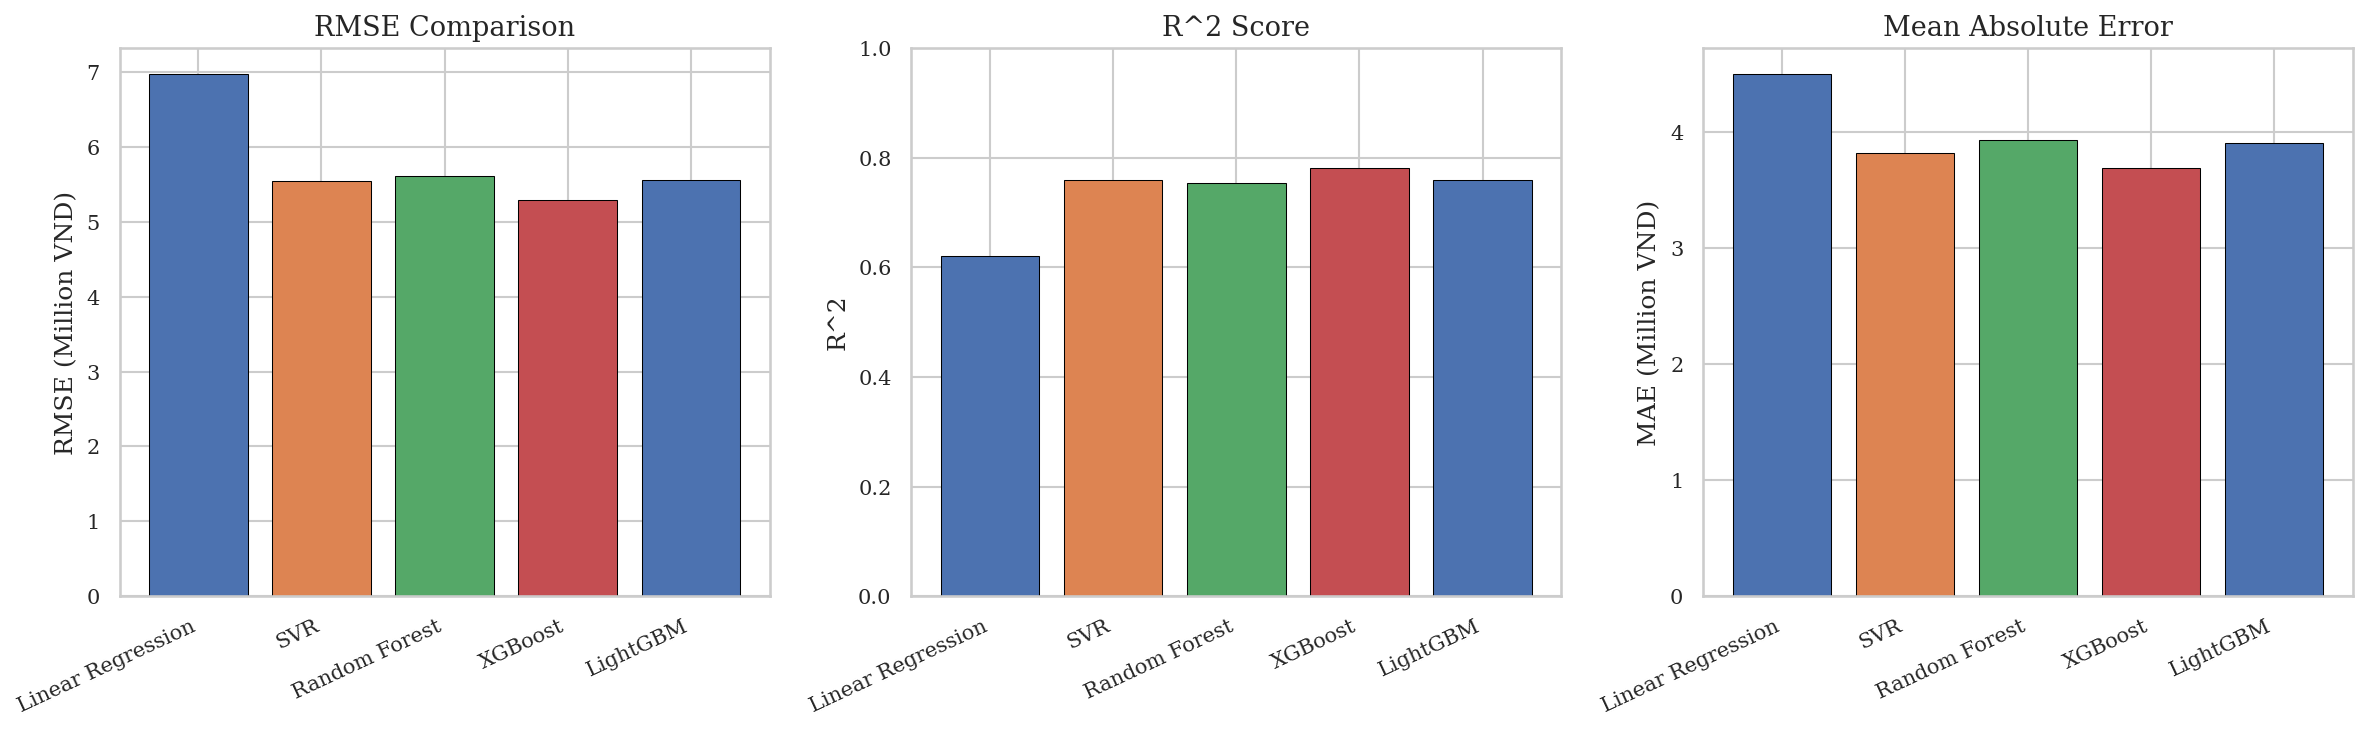

In [12]:
display_df = metrics_df.copy()
display_df["rmse_M"] = display_df["Test RMSE (VND)"] / 1e6
display_df["mae_M"] = display_df["Test MAE (VND)"] / 1e6
display_df["r2"] = display_df["Test R2"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = display_df["Model"].values
x = np.arange(len(models))
colors_bar = PALETTE[:len(models)]

# RMSE
axes[0].bar(x, display_df["rmse_M"].values, color=colors_bar, edgecolor="black", linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace("_", " ") for m in models], rotation=25, ha="right")
axes[0].set_ylabel("RMSE (Million VND)")
axes[0].set_title("RMSE Comparison")

# R2
axes[1].bar(x, display_df["r2"].values, color=colors_bar, edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace("_", " ") for m in models], rotation=25, ha="right")
axes[1].set_ylabel("R^2")
axes[1].set_title("R^2 Score")
axes[1].set_ylim(0, 1)

# MAE
axes[2].bar(x, display_df["mae_M"].values, color=colors_bar, edgecolor="black", linewidth=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels([m.replace("_", " ") for m in models], rotation=25, ha="right")
axes[2].set_ylabel("MAE (Million VND)")
axes[2].set_title("Mean Absolute Error")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison_metrics.png", bbox_inches="tight")
plt.show()


### Đánh giá Sai số RMSE theo từng Phân khúc Giá


In [13]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
X_train_sc = pd.read_csv(PROCESSED_DIR / "X_train_scaled.csv")
X_test_sc = pd.read_csv(PROCESSED_DIR / "X_test_scaled.csv")
y_train_raw = pd.read_csv(PROCESSED_DIR / "y_train.csv")["price_vnd"].values
y_train_log = np.log1p(y_train_raw)
y_test_raw = pd.read_csv(PROCESSED_DIR / "y_test.csv")["price_vnd"].values

models_dict = {}
models_dict["Linear Regression"] = np.expm1(Ridge(alpha=1.0, random_state=42).fit(X_train_sc, y_train_log).predict(X_test_sc))
models_dict["SVR"] = np.expm1(SVR(C=1.0, epsilon=0.2).fit(X_train_sc, y_train_log).predict(X_test_sc))
models_dict["Random Forest"] = RandomForestRegressor(
    n_estimators=150, max_depth=12, min_samples_leaf=2, max_features=0.8, random_state=42, n_jobs=-1
).fit(X_train.values, y_train_raw).predict(X_test.values)
models_dict["XGBoost"] = XGBRegressor(
    n_estimators=150, max_depth=5, learning_rate=0.08, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, random_state=42, n_jobs=-1
).fit(X_train.values, y_train_raw).predict(X_test.values)
models_dict["LightGBM"] = LGBMRegressor(
    n_estimators=150, max_depth=5, learning_rate=0.08, num_leaves=31, min_child_samples=15,
    subsample=0.7, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1
).fit(X_train.values, y_train_raw).predict(X_test.values)

segments = [
    (0, 10e6, "<10M VND"),
    (10e6, 20e6, "10-20M VND"),
    (20e6, 40e6, "20-40M VND"),
    (40e6, 60e6, "40-60M VND"),
    (60e6, 1e12, ">60M VND")
]

print("=" * 110)
print("PER-PRICE-SEGMENT RMSE (Million VND) FOR ALL MODELS")
print("=" * 110)
header = f"{'Segment':<25s}"
for mname in models_dict:
    header += f" {mname:>18s}"
header += f" {'N':>6s}"
print(header)
print("-" * 110)

for lo, hi, label in segments:
    mask = (y_test_raw >= lo) & (y_test_raw < hi)
    n = mask.sum()
    row = f"{label:<25s}"
    for mname, preds in models_dict.items():
        if n > 0:
            rmse_val = np.sqrt(mean_squared_error(y_test_raw[mask], preds[mask])) / 1e6
            row += f" {rmse_val:>18.2f}"
        else:
            row += f" {'N/A':>18s}"
    row += f" {n:>6d}"
    print(row)


PER-PRICE-SEGMENT RMSE (Million VND) FOR ALL MODELS
Segment                    Linear Regression                SVR      Random Forest            XGBoost           LightGBM      N
--------------------------------------------------------------------------------------------------------------
<10M VND                                3.44               3.36               4.48               4.11               4.23    233
10-20M VND                              6.23               5.66               6.76               6.58               6.80     88
20-40M VND                             10.46               8.38               7.83               7.90               7.89     82
40-60M VND                             21.28              11.73               6.68               5.19               5.68     11
>60M VND                                 N/A                N/A                N/A                N/A                N/A      0


d:\course_5\DSR\DSR\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Đóng góp Sai số của từng Phân khúc (MSE Contribution) & Top 10 Dự đoán Sai nhất


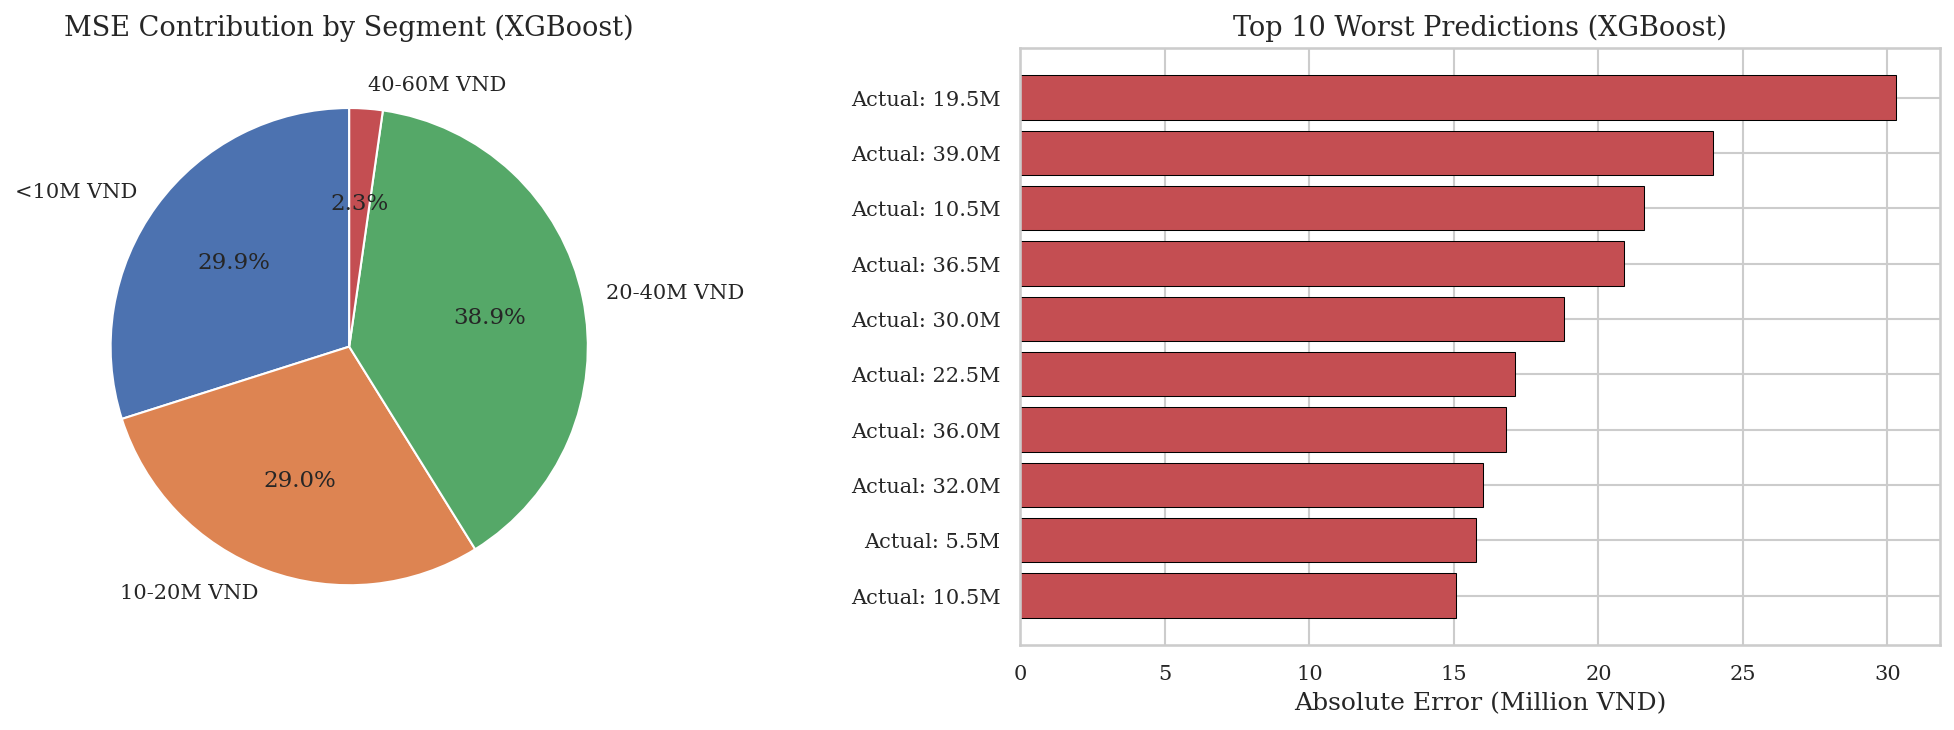

Top 10 worst predictions (XGBoost):
    Actual (M)  Predicted (M)  Error (M)
1        19.50          49.80      30.30
2        39.00          15.03      23.97
3        10.50          32.06      21.56
4        36.50          15.62      20.88
5        29.99          11.17      18.82
6        22.50           5.38      17.12
7        36.00          52.81      16.81
8        32.00          15.98      16.02
9         5.50          21.25      15.75
10       10.50          25.57      15.07


In [14]:
best_model_name = metrics_df.sort_values(by="Test R2", ascending=False).iloc[0]["Model"]
best_preds = models_dict[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contributions = []
labels_seg = []
for lo, hi, label in segments:
    mask = (y_test_raw >= lo) & (y_test_raw < hi)
    if mask.sum() > 0:
        sq_err = np.sum((y_test_raw[mask] - best_preds[mask])**2)
        contributions.append(sq_err)
        labels_seg.append(label)

total_sq = sum(contributions)
pcts = [c / total_sq * 100 for c in contributions]
colors_pie = PALETTE + [COLOR_BAD]
axes[0].pie(pcts, labels=labels_seg, autopct="%1.1f%%", colors=colors_pie[:len(pcts)], startangle=90)
axes[0].set_title(f"MSE Contribution by Segment ({best_model_name})")

# Top 10 worst predictions
errors_best = np.abs(y_test_raw - best_preds)
worst_idx = np.argsort(errors_best)[-10:][::-1]
worst_df = pd.DataFrame({
    "Actual (M)": y_test_raw[worst_idx] / 1e6,
    "Predicted (M)": best_preds[worst_idx] / 1e6,
    "Error (M)": errors_best[worst_idx] / 1e6,
})
worst_df = worst_df.reset_index(drop=True)
worst_df.index = range(1, 11)

# Plot worst predictions
axes[1].barh(range(10), worst_df["Error (M)"].values, color=COLOR_BAD, edgecolor="black", linewidth=0.5)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f"Actual: {a:.1f}M" for a in worst_df["Actual (M)"]])
axes[1].set_xlabel("Absolute Error (Million VND)")
axes[1].set_title(f"Top 10 Worst Predictions ({best_model_name})")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "mse_contribution_and_worst_predictions.png", bbox_inches="tight")
plt.show()

print(f"Top 10 worst predictions ({best_model_name}):")
print(worst_df.to_string())


### So sánh Mức độ Quan trọng của các Đặc trưng (Feature Importance)


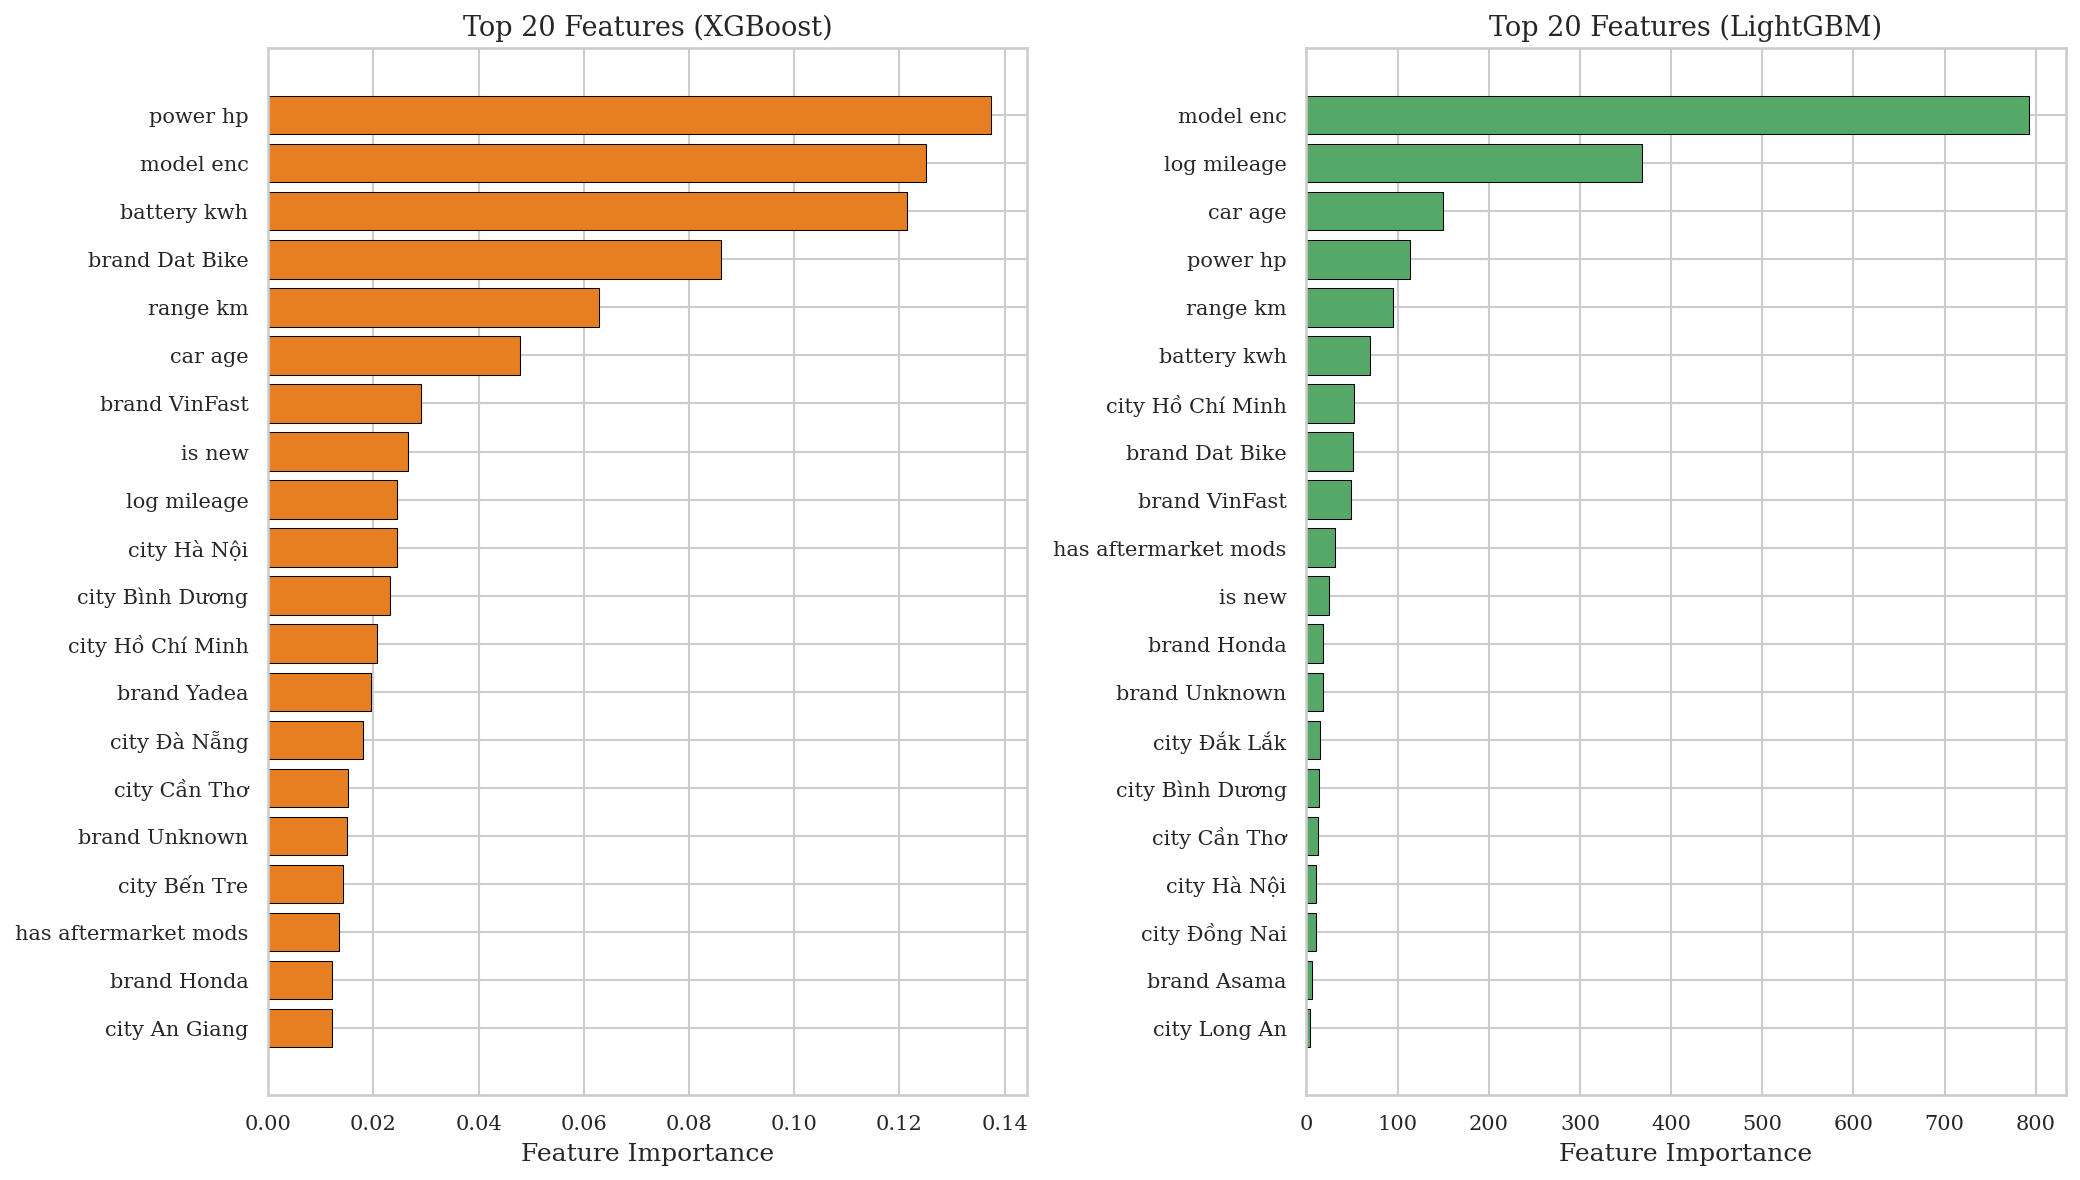

In [15]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
y_train_raw = pd.read_csv(PROCESSED_DIR / "y_train.csv")["price_vnd"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# XGBoost feature importance
xgb_model = XGBRegressor(
    n_estimators=150, max_depth=5, learning_rate=0.08, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, random_state=42, n_jobs=-1
).fit(X_train.values, y_train_raw)
xgb_importance = xgb_model.feature_importances_
feat_names = X_train.columns.tolist()
sorted_idx_xgb = np.argsort(xgb_importance)[-20:]
axes[0].barh(range(20), xgb_importance[sorted_idx_xgb], color=COLOR_ACCENT, edgecolor="black", linewidth=0.5)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([feat_names[i].replace("_", " ") for i in sorted_idx_xgb])
axes[0].set_xlabel("Feature Importance")
axes[0].set_title("Top 20 Features (XGBoost)")

# LightGBM feature importance
lgb_model = LGBMRegressor(
    n_estimators=150, max_depth=5, learning_rate=0.08, num_leaves=31, min_child_samples=15,
    subsample=0.7, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1
).fit(X_train.values, y_train_raw)
lgb_importance = lgb_model.feature_importances_
sorted_idx_lgb = np.argsort(lgb_importance)[-20:]
axes[1].barh(range(20), lgb_importance[sorted_idx_lgb], color=COLOR_GOOD, edgecolor="black", linewidth=0.5)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([feat_names[i].replace("_", " ") for i in sorted_idx_lgb])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 20 Features (LightGBM)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_importance_xgb_vs_lgb.png", bbox_inches="tight")
plt.show()


### Biểu đồ đánh giá của Mô hình tốt nhất
Hiển thị biểu đồ Giá trị dự đoán vs Giá trị thực tế và phân phối sai số (residuals) của mô hình tối ưu.

In [16]:
# Tải mô hình tốt nhất để vẽ hình trực quan ngay trong notebook
best_model_name = metrics_df.sort_values(by="Test R2", ascending=False).iloc[0]["Model"]
print(f"Mô hình tốt nhất được chọn: {best_model_name}")

# Tải dữ liệu scaled và unscaled đã lưu
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
X_train_scaled = pd.read_csv(PROCESSED_DIR / "X_train_scaled.csv")
X_test_scaled = pd.read_csv(PROCESSED_DIR / "X_test_scaled.csv")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["price_vnd"].values

# Tải lại kết quả đánh giá (chúng ta sẽ sinh lại hình trực tiếp)
import glob
from IPython.display import Image, display as ipy_display

# Đọc biểu đồ đã lưu dạng PNG
print("Các biểu đồ PNG đánh giá đã được tạo thành công trong thư mục: reports/two_wheelers/")


Mô hình tốt nhất được chọn: XGBoost
Các biểu đồ PNG đánh giá đã được tạo thành công trong thư mục: reports/two_wheelers/
